In [108]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler

In [109]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 2)
warnings.filterwarnings('ignore')

In [110]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"

In [111]:
parcels = pd.read_csv(clean + 'clean_parcels.csv')

adjustments = pd.read_csv(clean + 'parcels_with_adjustments.csv')
adj_cols = [f'adjustment_{R}' for R in np.arange(50, 800, 50)]
parcels = parcels.merge(adjustments[['parcelID'] + adj_cols], on = 'parcelID', how = 'left')

num_parcels = pd.read_csv(clean + 'parcels_with_num_parcels.csv')
parcels = parcels.merge(num_parcels, on = 'parcelID', how = 'left')

crimes = pd.read_csv(clean + 'clean_crimes.csv')

In [112]:
crimes = crimes.drop_duplicates(keep = 'first')

In [113]:
am = {
    'Brighton Heights': 6,
    'Marshall-Shadeland': 6,

    'Summer Hill': 6,
    'Spring Hill-City View': 6,
    'Troy Hill': 6,
    'Spring Garden': 6,
    'Northview Heights': 6,

    'Chateau': 7,
    'Manchester': 7,
    'California-Kirkbride': 7,
    'Allegheny Center': 7,
    'Central Northside': 7,
    'East Allegheny': 7,
    'Allegheny West': 7,

    'Perry North': 8,
    'Perry South': 8,
    'Fineview': 8,
    'North Shore': 8,

    'Strip District': 6,
    'Central Lawrenceville': 6,
    'Lower Lawrenceville': 6,
    'Upper Lawrenceville': 6,

    'Upper Hill': 6,
    'Polish Hill': 6,
    'Terrace Village': 6,
    'Bluff': 6,

    'Crawford-Roberts': 7,
    'Middle Hill': 7,
    'Bedford Dwellings': 7,

    'Central Business District': 11,

    'South Side Flats': 7,
    'South Shore': 7,

    'Duquesne Heights': 7,
    'Mount Washington': 7,
    'Beltzhoover': 7,
    'Allentown': 7,

    'Bon Air': 7,
    'Knoxville': 7,
    'Carrick': 7,
    'Overbrook': 7,

    'Mt. Oliver': 5,
    'St. Clair': 5,
    'Arlington Heights': 5,
    'Arlington': 5,
    'South Side Slopes': 5,

    'Squirrel Hill North': 9,
    'Squirrel Hill South': 9,
    'Point Breeze': 9,
    'Point Breeze North': 9,
    'Regent Square': 9,

    'North Oakland': 8,
    'Central Oakland': 8,
    'South Oakland': 8,
    'West Oakland': 8,
    'Shadyside': 8,

    'Hazelwood': 8,
    'Greenfield': 8,
    'Glen Hazel': 8,
    'Duck Hollow': 8,
    'Swisshelm Park': 8,

    'Hays': 11,
    'New Homestead': 11,
    'Lincoln Place': 11,

    'Bloomfield': 6,
    'Garfield': 6,
    'Friendship': 6,

    'Stanton Heights': 5,
    'Morningside': 5,
    'East Liberty': 5,

    'Lincoln-Lemington-Belmar': 7,
    'Highland Park': 7,
    'Larimer': 7,

    'Homewood West': 11,
    'Homewood North': 11,
    'Homewood South': 11,
    'East Hills': 11,

    'Elliott': 7,
    'Crafton Heights': 7,
    'West End': 7,
    'Westwood': 7,
    'Oakwood': 7,
    'East Carnegie': 7,

    'Sheraden': 6,
    'Esplen': 6,
    'Chartiers City': 6,
    'Windgap': 6,
    'Fairywood': 6,

    'Brookline': 7,
    'Beechview': 7,
    'Banksville': 7,
    'Ridgemont': 7
}

In [114]:
pm = {
    'Brighton Heights': 9,
    'Marshall-Shadeland': 9,

    'Summer Hill': 6,
    'Spring Hill-City View': 6,
    'Troy Hill': 6,
    'Spring Garden': 6,
    'Northview Heights': 6,

    'Chateau': 9,
    'Manchester': 9,
    'California-Kirkbride': 9,
    'Allegheny Center': 9,
    'Central Northside': 9,
    'East Allegheny': 9,
    'Allegheny West': 9,

    'Perry North': 6,
    'Perry South': 6,
    'Fineview': 6,
    'North Shore': 6,

    'Strip District': 5,
    'Central Lawrenceville': 5,
    'Lower Lawrenceville': 5,
    'Upper Lawrenceville': 5,

    'Upper Hill': 5,
    'Polish Hill': 5,
    'Terrace Village': 5,
    'Bluff': 5,

    'Crawford-Roberts': 5,
    'Middle Hill': 5,
    'Bedford Dwellings': 5,

    'Central Business District': 9,

    'South Side Flats': 6,
    'South Shore': 6,

    'Duquesne Heights': 9,
    'Mount Washington': 9,
    'Beltzhoover': 9,
    'Allentown': 9,

    'Bon Air': 9,
    'Knoxville': 9,
    'Carrick': 9,
    'Overbrook': 9,

    'Mt. Oliver': 7,
    'St. Clair': 7,
    'Arlington Heights': 7,
    'Arlington': 7,
    'South Side Slopes': 7,

    'Squirrel Hill North': 7,
    'Squirrel Hill South': 7,
    'Point Breeze': 7,
    'Point Breeze North': 7,
    'Regent Square': 7,

    'North Oakland': 5,
    'Central Oakland': 5,
    'South Oakland': 5,
    'West Oakland': 5,
    'Shadyside': 5,

    'Hazelwood': 10,
    'Greenfield': 10,
    'Glen Hazel': 10,
    'Duck Hollow': 10,
    'Swisshelm Park': 10,

    'Hays': 10,
    'New Homestead': 10,
    'Lincoln Place': 10,

    'Bloomfield': 7,
    'Garfield': 7,
    'Friendship': 7,

    'Stanton Heights': 7,
    'Morningside': 7,
    'East Liberty': 7,

    'Lincoln-Lemington-Belmar': 10,
    'Highland Park': 10,
    'Larimer': 10,

    'Homewood West': 11,
    'Homewood North': 11,
    'Homewood South': 11,
    'East Hills': 11,

    'Elliott': 8,
    'Crafton Heights': 8,
    'West End': 8,
    'Westwood': 8,
    'Oakwood': 8,
    'East Carnegie': 8,

    'Sheraden': 7,
    'Esplen': 7,
    'Chartiers City': 7,
    'Windgap': 7,
    'Fairywood': 7,

    'Brookline': 5,
    'Beechview': 5,
    'Banksville': 5,
    'Ridgemont': 5
}

In [115]:
crimes = crimes.assign(
    am = np.where(pd.to_datetime(crimes['date'], format = 'mixed').dt.hour < 12, 1, 0),
    pm = np.where(pd.to_datetime(crimes['date'], format = 'mixed').dt.hour >= 12, 1, 0)
)

In [116]:
am_crimes = crimes.loc[crimes['am'] == 1]
pm_crimes = crimes.loc[crimes['pm'] == 1]

In [117]:
am_crimes['weight'] = 1 / am_crimes['nbrhd'].map(am)
pm_crimes['weight'] = 1 / pm_crimes['nbrhd'].map(pm)

crimes = pd.concat([am_crimes, pm_crimes], axis = 0).reset_index(drop = True)

In [118]:
low = crimes.loc[crimes['severity'] == 'Low'].reset_index(drop = True)
high = crimes.loc[crimes['severity'] == 'High'].reset_index(drop = True)

### Count crime incidents

In [119]:
# convert geocodes to radians
parcels_coords = np.radians(parcels[['lat', 'lng']].values)
low_coords = np.radians(low[['lat', 'lng']].values)

In [120]:
# earth's radius in meters
earth_radius = 6_378_137 # chat-gpt said 6,371,000 but university of southern florida disagrees. I'm using USF

crime_tree = BallTree(low_coords, metric = 'haversine')

In [121]:
# distance bins
distances = np.arange(50, 800, 50)
distances_radians = distances / earth_radius

In [122]:
# count violations in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = crime_tree.query_radius(parcels_coords, r = d_r)
    sums = [crimes.loc[idxs, 'weight'].sum() for idxs in indices_within_radius]
    parcels[f'low_count_{d_m}'] = sums
    # counts = [len(idxs) for idxs in indices_within_radius]
    # parcels[f'low_count_{d_m}'] = counts

In [123]:
for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'low_count_{r}'] -= parcels[f'low_count_{distances[::-1][i + 1]}']

### Adjusting for measurement area outside of the city boundary

In [124]:
for r in distances:
    parcels[f'low_count_{r}'] = parcels[f'low_count_{r}'] / parcels[f'adjustment_{r}']

### Divide by num_parcels to get BPU (blight-per-unit)

In [125]:
# for r in distances:
#     parcels[f'low_count_{r}'] = parcels[f'low_count_{r}'] / parcels[f'parcels_count_{r}']

### Distance decay and sum across bins for score

In [126]:
weights = [(len(distances) - i) / len(distances) for i, r in enumerate(distances)]

In [127]:
parcels['low_score'] = (parcels.iloc[:, -len(distances):] * weights).sum(axis = 1)
parcels = parcels.loc[parcels['low_score'] != -np.inf]

### Transformations

In [128]:
parcels['low_log'] = np.log1p(parcels['low_score'])
parcels['low_sqrt'] = np.sqrt(parcels['low_score'])

### Count crime incidents

In [129]:
# convert geocodes to radians
parcels_coords = np.radians(parcels[['lat', 'lng']].values)
high_coords = np.radians(high[['lat', 'lng']].values)

In [130]:
# earth's radius in meters
earth_radius = 6_378_137 # chat-gpt said 6,371,000 but university of southern florida disagrees. I'm using USF

crime_tree = BallTree(high_coords, metric = 'haversine')

In [131]:
# distance bins
distances = np.arange(50, 800, 50)
distances_radians = distances / earth_radius

In [132]:
# count violations in each distance bin
for d_m, d_r in zip(distances, distances_radians):
    indices_within_radius = crime_tree.query_radius(parcels_coords, r = d_r)
    sums = [crimes.loc[idxs, 'weight'].sum() for idxs in indices_within_radius]
    parcels[f'high_count_{d_m}'] = sums
    # counts = [len(idxs) for idxs in indices_within_radius]
    # parcels[f'high_count_{d_m}'] = counts

In [133]:
for i, r in enumerate(distances[::-1]):
    if r != distances[0]:
        parcels[f'high_count_{r}'] -= parcels[f'high_count_{distances[::-1][i + 1]}']

### Adjusting for measurement area outside of the city boundary

In [134]:
for r in distances:
    parcels[f'high_count_{r}'] = parcels[f'high_count_{r}'] / parcels[f'adjustment_{r}']

### Divide by num_parcels to get BPU (blight-per-unit)

In [ ]:
# for r in distances:
#     parcels[f'high_count_{r}'] = parcels[f'high_count_{r}'] / parcels[f'parcels_count_{r}']

### Distance decay and sum across bins for score

In [135]:
weights = [(len(distances) - i) / len(distances) for i, r in enumerate(distances)]

In [136]:
parcels['high_score'] = (parcels.iloc[:, -len(distances):] * weights).sum(axis = 1)
parcels = parcels.loc[parcels['high_score'] != -np.inf]

### Transformations

In [137]:
parcels['high_log'] = np.log1p(parcels['high_score'])
parcels['high_sqrt'] = np.sqrt(parcels['high_score'])

### Concatenating low and high

In [139]:
pd.concat([parcels.iloc[:, :5], parcels.iloc[:, 52:55], parcels.iloc[:, -3:]], axis = 1)

,parcelID,lat,lng,nbrhd,tract,low_score,low_log,low_sqrt,high_score,high_log,high_sqrt
0,0001A00100000000,40.44,-80.01,Central Business District,20100,62.36,4.15,7.90,46.21,3.85,6.80
1,0001B00010000000,40.44,-80.01,Central Business District,20100,147.18,5.00,12.13,98.66,4.60,9.93
2,0001B00024000000,40.44,-80.01,Central Business District,20100,86.37,4.47,9.29,57.57,4.07,7.59
3,0001B00026000000,40.44,-80.01,Central Business District,20100,91.10,4.52,9.54,59.53,4.10,7.72
4,0001B00050000000,40.44,-80.01,Central Business District,20100,105.46,4.67,10.27,71.53,4.28,8.46
...,...,...,...,...,...,...,...,...,...,...,...
144026,8000T04522000000,40.40,-80.00,Brookline,320600,47.25,3.88,6.87,22.02,3.14,4.69
144027,8000T04662000000,40.39,-80.00,Brookline,320600,46.10,3.85,6.79,21.50,3.11,4.64
144028,8000T04810000000,40.41,-80.03,Banksville,202300,16.38,2.86,4.05,9.21,2.32,3.03
144029,8000T04973000000,40.45,-80.07,Windgap,563000,30.15,3.44,5.49,21.46,3.11,4.63


In [140]:
parcels = pd.concat([parcels.iloc[:, :5], parcels.iloc[:, 52:55], parcels.iloc[:, -3:]], axis = 1)

In [141]:
parcels.to_csv(clean + 'crimes_transformations.csv', index = False)

In [69]:
parcels = pd.read_csv(clean + 'crimes_transformations.csv')

### Exploring skew and the effects of transformations

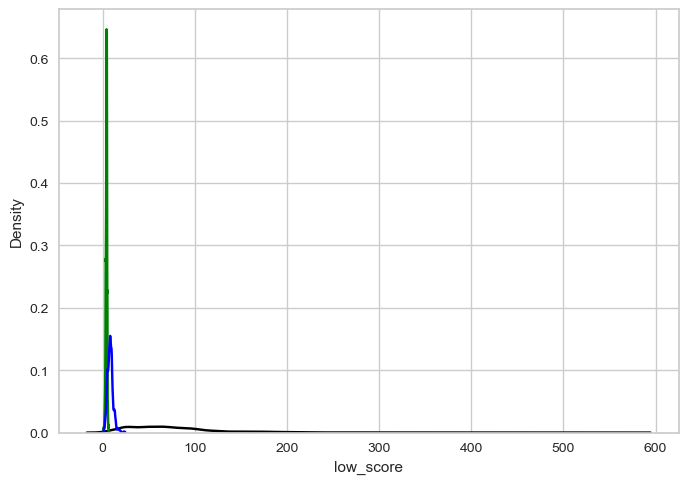

In [142]:
sns.kdeplot(parcels['low_score'], color = 'black')
sns.kdeplot(parcels['low_log'], color = 'green')
sns.kdeplot(parcels['low_sqrt'], color = 'blue')
plt.show()

In [144]:
skew(parcels['low_score']), skew(parcels['low_log']), skew(parcels['low_sqrt'])

(np.float64(2.7331656600018843),
 np.float64(-0.6162265750806405),
 np.float64(0.8905461710863439))

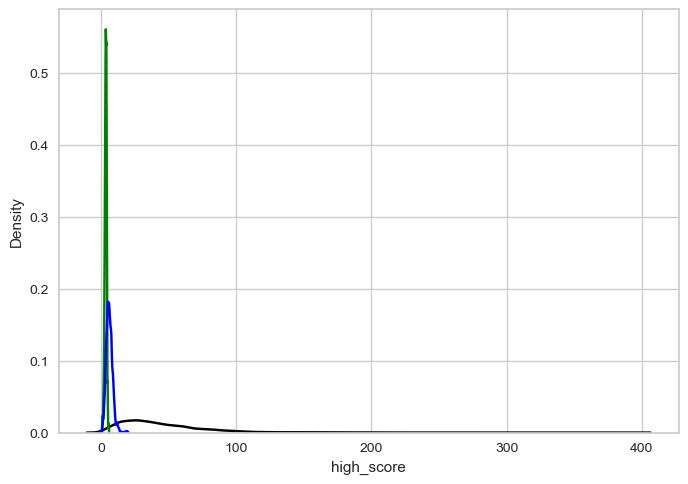

In [145]:
sns.kdeplot(parcels['high_score'], color = 'black')
sns.kdeplot(parcels['high_log'], color = 'green')
sns.kdeplot(parcels['high_sqrt'], color = 'blue')
plt.show()

In [146]:
skew(parcels['high_score']), skew(parcels['high_log']), skew(parcels['high_sqrt'])

(np.float64(3.2179167367965396),
 np.float64(-0.47121600619692156),
 np.float64(0.9531023505752296))